# Pseudobulk global alignment

Evaluate whether the top CLAMPfull LV assigned to each true cell proportion is also biologically aligned with that same cell type through the ORA databases used in the pseudobulk biology notebook.

In [1]:
suppressPackageStartupMessages({
    library(here)
    library(dplyr)
    library(tidyr)
    library(stringr)
    library(ggplot2)
})

BIO_DIR <- here('output', '03_model_biology', '02_pseudobulk', '01_biology')
OUT_DIR <- here('output', '03_model_biology', '02_pseudobulk', '03_global_alignment')
dir.create(OUT_DIR, recursive = TRUE, showWarnings = FALSE)

TOP_LVS_PATH <- file.path(BIO_DIR, 'top_lvs_per_celltype.csv')
ORA_PATH     <- file.path(BIO_DIR, 'lv_cellmarker_ora.csv')
LABEL_PATH   <- here('data', 'pseudobulk', 'cell_type_labels.csv')

FDR_ORA <- 0.25
BRAIN_DS <- c('Brain_Mathys2023', 'Brain_Xiong2023')
IMMUNE_DS <- c('PBMC_1k1k', 'PBMC_Perez2022', 'BRCA_Bassez2021', 'CRC_Pelka2021')


In [2]:
top_lvs <- read.csv(TOP_LVS_PATH, stringsAsFactors = FALSE)
ora <- read.csv(ORA_PATH, stringsAsFactors = FALSE)
labels <- read.csv(LABEL_PATH, stringsAsFactors = FALSE)
label_lookup <- setNames(labels$label, labels$cell_type)

cat('Top LV rows:', nrow(top_lvs), '\n')
cat('ORA rows:', nrow(ora), '\n')
print(table(top_lvs$dataset))


Top LV rows: 35 


ORA rows: 9814 



Brain_Mathys2023  Brain_Xiong2023    CRC_Pelka2021        PBMC_1k1k 
               7                7                8                9 
  PBMC_Perez2022 
               4 


In [3]:
allowed_db_for_dataset <- function(dataset) {
    dbs <- 'c8'
    if (dataset %in% BRAIN_DS) dbs <- c(dbs, 'allen')
    if (dataset %in% IMMUNE_DS) dbs <- c(dbs, 'c7')
    dbs
}

ora_allowed <- ora %>%
    dplyr::rowwise() %>%
    dplyr::filter(db %in% allowed_db_for_dataset(dataset)) %>%
    dplyr::ungroup() %>%
    dplyr::filter(padj < FDR_ORA)

cat('Allowed significant ORA rows:', nrow(ora_allowed), '\n')
print(table(ora_allowed$db, ora_allowed$dataset))


Allowed significant ORA rows: 9814 


       
        Brain_Mathys2023 Brain_Xiong2023 CRC_Pelka2021 PBMC_1k1k PBMC_Perez2022
  allen               44              72             0         0              0
  c7                   0               0          2161      3286           1215
  c8                 383             428           718      1161            346


In [4]:
normalize_text <- function(x) {
    x <- tolower(x)
    x <- gsub('[^a-z0-9]+', ' ', x)
    stringr::str_squish(x)
}

alias_map <- list(
    Ast = c('astrocyte'),
    Exc = c('excitatory neuron', 'glutamatergic neuron', 'glutamatergic cell'),
    Inh = c('inhibitory neuron', 'gabaergic neuron', 'gabaergic cell'),
    Mic = c('microglia', 'microglial'),
    Oli = c('oligodendrocyte'),
    Opc = c('oligodendrocyte precursor', 'oligodendrocyte progenitor', 'opc'),
    Vas = c('vascular', 'endothelial cell', 'pericyte', 'smooth muscle cell'),
    B_cell = c('b cell', 'b lymphocyte'),
    CD14_Mono = c('cd14 monocyte', 'cd14 positive monocyte', 'classical monocyte'),
    CD16_Mono = c('cd16 monocyte', 'cd16 positive monocyte', 'non classical monocyte', 'nonclassical monocyte'),
    CD4_T = c('cd4 t cell', 'cd4 positive t cell', 'cd4 lymphocyte'),
    CD8_T = c('cd8 t cell', 'cd8 positive t cell', 'cd8 lymphocyte'),
    DC = c('dendritic cell'),
    gd_T = c('gamma delta t cell', 'gd t cell', 'gammadelta t cell'),
    NK = c('natural killer', 'nk cell'),
    Plasma_B = c('plasma cell', 'plasma b cell', 'antibody secreting cell'),
    T_cell = c('t cell', 't lymphocyte'),
    Myeloid = c('myeloid', 'monocyte', 'macrophage'),
    Myeloid_cell = c('myeloid', 'monocyte', 'macrophage'),
    Dendritic = c('dendritic cell'),
    Endothelial = c('endothelial cell'),
    Endothelial_cell = c('endothelial cell'),
    Fibroblast = c('fibroblast'),
    Malignant = c('malignant', 'cancer cell', 'tumor cell', 'carcinoma'),
    Mast = c('mast cell'),
    Mast_cell = c('mast cell'),
    Cancer_cell = c('cancer cell', 'malignant', 'tumor cell', 'carcinoma'),
    pDC = c('plasmacytoid dendritic', 'pdc')
)

match_aliases <- function(cell_type, terms) {
    aliases <- alias_map[[cell_type]]
    if (is.null(aliases)) aliases <- normalize_text(label_lookup[[cell_type]])
    aliases_norm <- normalize_text(aliases)
    terms_norm <- normalize_text(terms)
    matched <- vapply(terms_norm, function(term) {
        any(vapply(aliases_norm, function(alias) stringr::str_detect(term, stringr::fixed(alias)), logical(1)))
    }, logical(1))
    matched
}


In [5]:
term_universe <- sort(unique(ora_allowed$term))
expected_matching <- dplyr::bind_rows(lapply(names(alias_map), function(ct) {
    hits <- term_universe[match_aliases(ct, term_universe)]
    data.frame(
        cell_type = ct,
        label = ifelse(ct %in% names(label_lookup), label_lookup[[ct]], ct),
        aliases = paste(alias_map[[ct]], collapse = '; '),
        n_matching_significant_terms = length(hits),
        example_terms = paste(head(hits, 5), collapse = ' | '),
        stringsAsFactors = FALSE
    )
}))

expected_matching %>% arrange(cell_type)


cell_type,label,aliases,n_matching_significant_terms,example_terms
<chr>,<chr>,<chr>,<int>,<chr>
Ast,Astrocytes,astrocyte,9,DESCARTES_FETAL_CEREBELLUM_ASTROCYTES | DESCARTES_FETAL_CEREBRUM_ASTROCYTES | DESCARTES_FETAL_EYE_ASTROCYTES | DESCARTES_MAIN_FETAL_ASTROCYTES | FAN_EMBRYONIC_CTX_ASTROCYTE_1
B_cell,B cells,b cell; b lymphocyte,28,AIZARANI_LIVER_C22_RESIDENT_B_CELLS_2 | AIZARANI_LIVER_C34_MHC_II_POS_B_CELLS | AIZARANI_LIVER_C38_RESIDENT_B_CELLS_3 | AIZARANI_LIVER_C8_RESIDENT_B_CELLS_1 | DURANTE_ADULT_OLFACTORY_NEUROEPITHELIUM_B_CELLS
CD14_Mono,CD14+ Monocytes,cd14 monocyte; cd14 positive monocyte; classical monocyte,4,HE_LIM_SUN_FETAL_LUNG_C2_NON_CLASSICAL_MONOCYTE | HE_LIM_SUN_FETAL_LUNG_C2_S100A12_HI_CLASSICAL_MONOCYTE | TRAVAGLINI_LUNG_CLASSICAL_MONOCYTE_CELL | TRAVAGLINI_LUNG_NONCLASSICAL_MONOCYTE_CELL
CD16_Mono,CD16+ Monocytes,cd16 monocyte; cd16 positive monocyte; non classical monocyte; nonclassical monocyte,2,HE_LIM_SUN_FETAL_LUNG_C2_NON_CLASSICAL_MONOCYTE | TRAVAGLINI_LUNG_NONCLASSICAL_MONOCYTE_CELL
CD4_T,CD4+ T cells,cd4 t cell; cd4 positive t cell; cd4 lymphocyte,2,DURANTE_ADULT_OLFACTORY_NEUROEPITHELIUM_CD4_T_CELLS | HE_LIM_SUN_FETAL_LUNG_C4_CD4_T_CELL
CD8_T,CD8+ T cells,cd8 t cell; cd8 positive t cell; cd8 lymphocyte,11,DURANTE_ADULT_OLFACTORY_NEUROEPITHELIUM_CD8_T_CELLS | GSE15930_STIM_VS_STIM_AND_IFNAB_48H_CD8_T_CELL_UP | GSE15930_STIM_VS_STIM_AND_IFNAB_72H_CD8_T_CELL_UP | GSE15930_STIM_VS_STIM_AND_IL12_48H_CD8_T_CELL_DN | GSE15930_STIM_VS_STIM_AND_IL12_48H_CD8_T_CELL_UP
Cancer_cell,Cancer cells,cancer cell; malignant; tumor cell; carcinoma,0,
DC,Dendritic cells,dendritic cell,13,BUSSLINGER_ESOPHAGEAL_DENDRITIC_CELLS | DURANTE_ADULT_OLFACTORY_NEUROEPITHELIUM_DENDRITIC_CELLS | HAY_BONE_MARROW_DENDRITIC_CELL | HOEK_MYELOID_DENDRITIC_CELL_2011_2012_TIV_ADULT_1DY_UP | HOEK_MYELOID_DENDRITIC_CELL_2011_2012_TIV_ADULT_7DY_UP
Dendritic,Dendritic cells,dendritic cell,13,BUSSLINGER_ESOPHAGEAL_DENDRITIC_CELLS | DURANTE_ADULT_OLFACTORY_NEUROEPITHELIUM_DENDRITIC_CELLS | HAY_BONE_MARROW_DENDRITIC_CELL | HOEK_MYELOID_DENDRITIC_CELL_2011_2012_TIV_ADULT_1DY_UP | HOEK_MYELOID_DENDRITIC_CELL_2011_2012_TIV_ADULT_7DY_UP


In [6]:
detail_rows <- lapply(seq_len(nrow(top_lvs)), function(i) {
    row <- top_lvs[i, , drop = FALSE]
    x <- ora_allowed[ora_allowed$dataset == row$dataset & ora_allowed$LV == row$LV, , drop = FALSE]
    hit <- match_aliases(row$cell_type, x$term)
    matched <- unique(x$term[hit])

    data.frame(
        dataset = row$dataset,
        cell_type = row$cell_type,
        cell_type_label = ifelse(row$cell_type %in% names(label_lookup), label_lookup[[row$cell_type]], row$cell_type),
        LV = row$LV,
        cor = row$cor,
        allowed_dbs = paste(allowed_db_for_dataset(row$dataset), collapse = ';'),
        n_sig_terms = nrow(x),
        n_true_terms = length(matched),
        true_recovered = length(matched) > 0,
        best_true_padj = if (length(matched) > 0) min(x$padj[hit], na.rm = TRUE) else NA_real_,
        matched_terms = paste(matched, collapse = ' | '),
        stringsAsFactors = FALSE
    )
})

detail <- dplyr::bind_rows(detail_rows)

summary_by_dataset <- detail %>%
    dplyr::group_by(dataset) %>%
    dplyr::summarise(
        n_cell_types = dplyr::n(),
        n_recovered = sum(true_recovered),
        recovery_pct = 100 * mean(true_recovered),
        .groups = 'drop'
    )

global_summary <- data.frame(
    dataset = 'GLOBAL',
    n_cell_types = nrow(detail),
    n_recovered = sum(detail$true_recovered),
    recovery_pct = 100 * mean(detail$true_recovered),
    stringsAsFactors = FALSE
)

summary_out <- dplyr::bind_rows(summary_by_dataset, global_summary)

write.csv(detail, file.path(OUT_DIR, 'pseudobulk_global_alignment_detail.csv'), row.names = FALSE)
write.csv(summary_out, file.path(OUT_DIR, 'pseudobulk_global_alignment_summary.csv'), row.names = FALSE)

summary_out


dataset,n_cell_types,n_recovered,recovery_pct
<chr>,<int>,<int>,<dbl>
Brain_Mathys2023,7,5,71.42857
Brain_Xiong2023,7,4,57.14286
CRC_Pelka2021,8,5,62.50000
PBMC_1k1k,9,7,77.77778
PBMC_Perez2022,4,4,100.00000
GLOBAL,35,25,71.42857


In [7]:
detail %>%
    dplyr::select(dataset, cell_type, cell_type_label, LV, cor, true_recovered, n_sig_terms, n_true_terms, best_true_padj, matched_terms) %>%
    dplyr::arrange(dataset, cell_type)


dataset          cell_type   cell_type_label                 LV   cor      
1  Brain_Mathys2023 Ast         Astrocytes                      LV17 0.8911263
2  Brain_Mathys2023 Exc         Excitatory neurons              LV11 0.6028913
3  Brain_Mathys2023 Inh         Inhibitory neurons              LV4  0.8155799
4  Brain_Mathys2023 Mic         Microglia                       LV6  0.9655128
5  Brain_Mathys2023 Oli         Oligodendrocytes                LV18 0.9617558
6  Brain_Mathys2023 Opc         Oligodendrocyte Precursor Cells LV7  0.4715819
7  Brain_Mathys2023 Vas         Vascular cells                  LV12 0.3293936
8  Brain_Xiong2023  Ast         Astrocytes                      LV5  0.9427029
9  Brain_Xiong2023  Exc         Excitatory neurons              LV13 0.7277295
10 Brain_Xiong2023  Inh         Inhibitory neurons              LV2  0.6067130
11 Brain_Xiong2023  Mic         Microglia                       LV16 0.9305612
12 Brain_Xiong2023  Oli         Oligodendrocytes                LV14 0.9865262
13 Brain_Xiong2023  Opc         Oligodendrocyte Precursor Cells LV11 0.4875953
14 Brain_Xiong2023  Vas         Vascular cells                  LV15 0.3759212
15 CRC_Pelka2021    B_cell      B cells                         LV10 0.4648483
16 CRC_Pelka2021    Dendritic   Dendritic cells                 LV5  0.4812470
17 CRC_Pelka2021    Endothelial Endothelial cells               LV7  0.3572515
18 CRC_Pelka2021    Fibroblast  Fibroblasts                     LV11 0.9264766
19 CRC_Pelka2021    Malignant   Malignant cells                 LV6  0.6500734
20 CRC_Pelka2021    Mast        Mast cells                      LV1  0.1055037
21 CRC_Pelka2021    Myeloid     Myeloid cells                   LV4  0.9556237
22 CRC_Pelka2021    T_cell      T cells                         LV3  0.9061182
23 PBMC_1k1k        B_cell      B cells                         LV58 0.7724319
24 PBMC_1k1k        CD14_Mono   CD14+ Monocytes                 LV2  0.9890208
25 PBMC_1k1k        CD16_Mono   CD16+ Monocytes                 LV20 0.9400003
26 PBMC_1k1k        CD4_T       CD4+ T cells                    LV28 0.8538607
27 PBMC_1k1k        CD8_T       CD8+ T cells                    LV4  0.7930019
28 PBMC_1k1k        DC          Dendritic cells                 LV69 0.2195646
29 PBMC_1k1k        NK          NK cells                        LV43 0.9187272
30 PBMC_1k1k        Plasma_B    Plasma B cells                  LV22 0.8732784
31 PBMC_1k1k        gd_T        gd T cells                      LV48 0.2939866
32 PBMC_Perez2022   B_cell      B cells                         LV10 0.9541733
33 PBMC_Perez2022   Myeloid     Myeloid cells                   LV2  0.8857064
34 PBMC_Perez2022   NK          NK cells                        LV6  0.8906286
35 PBMC_Perez2022   T_cell      T cells                         LV52 0.8393497
   true_recovered n_sig_terms n_true_terms best_true_padj
1   TRUE          162           7           3.884265e-22 
2   TRUE           29           1           2.020479e-01 
3  FALSE           30           0                     NA 
4   TRUE          156           8          1.956190e-116 
5   TRUE           19           2           6.169615e-02 
6   TRUE           31           4           1.481650e-05 
7  FALSE            0           0                     NA 
8   TRUE          148           8           5.337058e-33 
9  FALSE            5           0                     NA 
10 FALSE          104           0                     NA 
11  TRUE          172           8           1.830641e-77 
12  TRUE           48           2           3.053677e-05 
13  TRUE           23           5           1.277627e-09 
14 FALSE            0           0                     NA 
15  TRUE          370          11           4.201655e-61 
16 FALSE           87           0                     NA 
17  TRUE          102           3           1.049182e-01 
18  TRUE          305          16           1.025070e-49 
19 FALSE          418           0                     NA 

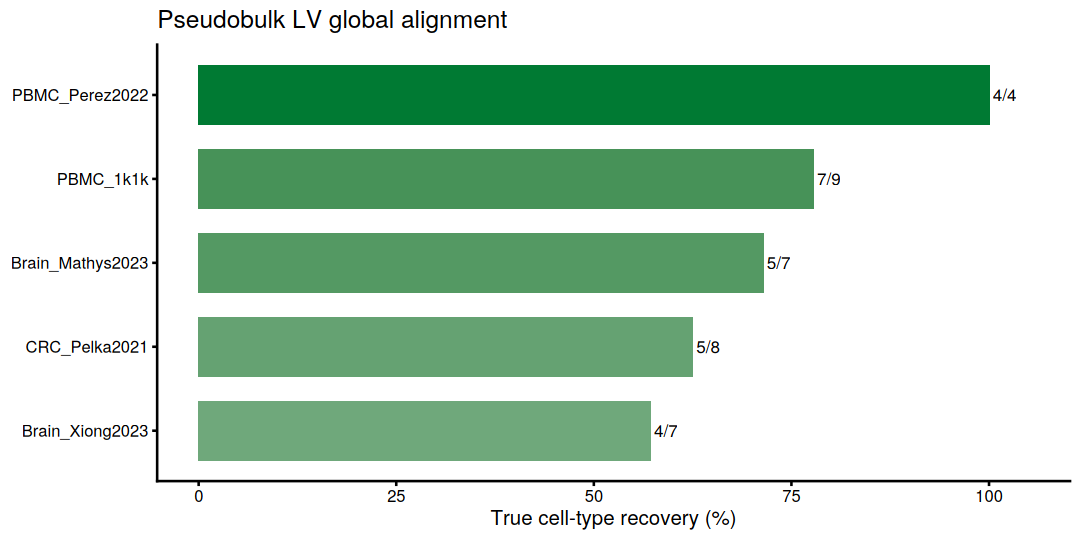

In [8]:
options(repr.plot.width = 9, repr.plot.height = 4.5)
ggplot(summary_by_dataset, aes(x = reorder(dataset, recovery_pct), y = recovery_pct, fill = recovery_pct)) +
    geom_col(width = 0.7) +
    geom_text(aes(label = sprintf('%d/%d', n_recovered, n_cell_types)), hjust = -0.15, size = 3.5) +
    coord_flip(ylim = c(0, 105)) +
    scale_fill_gradient(low = '#d9e6e2', high = '#007a33', limits = c(0, 100), guide = 'none') +
    labs(x = NULL, y = 'True cell-type recovery (%)', title = 'Pseudobulk LV global alignment') +
    theme_classic(base_size = 12)


In [9]:
stopifnot(nrow(detail) == nrow(top_lvs))
stopifnot(file.exists(file.path(OUT_DIR, 'pseudobulk_global_alignment_detail.csv')))
stopifnot(file.exists(file.path(OUT_DIR, 'pseudobulk_global_alignment_summary.csv')))
cat('Checks passed. Denominator =', nrow(detail), 'top LV/cell-type rows.\n')


Checks passed. Denominator = 35 top LV/cell-type rows.
